In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/loan_data.csv")

In [3]:
df.shape

(45000, 14)

In [5]:
df["loan_status"].value_counts()

loan_status
0    35000
1    10000
Name: count, dtype: int64

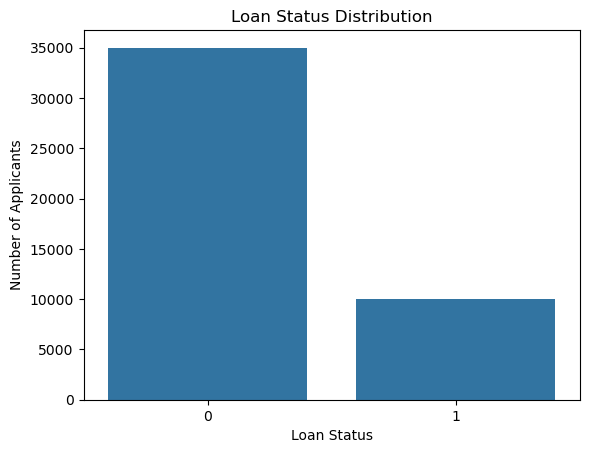

In [4]:
sns.countplot(data=df, x="loan_status")
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")
plt.show()

In [6]:
numeric_cols = df.select_dtypes(include=np.number).columns

numeric_cols

Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'loan_status'],
      dtype='object')

In [7]:
numeric_features = [
    col for col in numeric_cols
    if col != "loan_status"
]

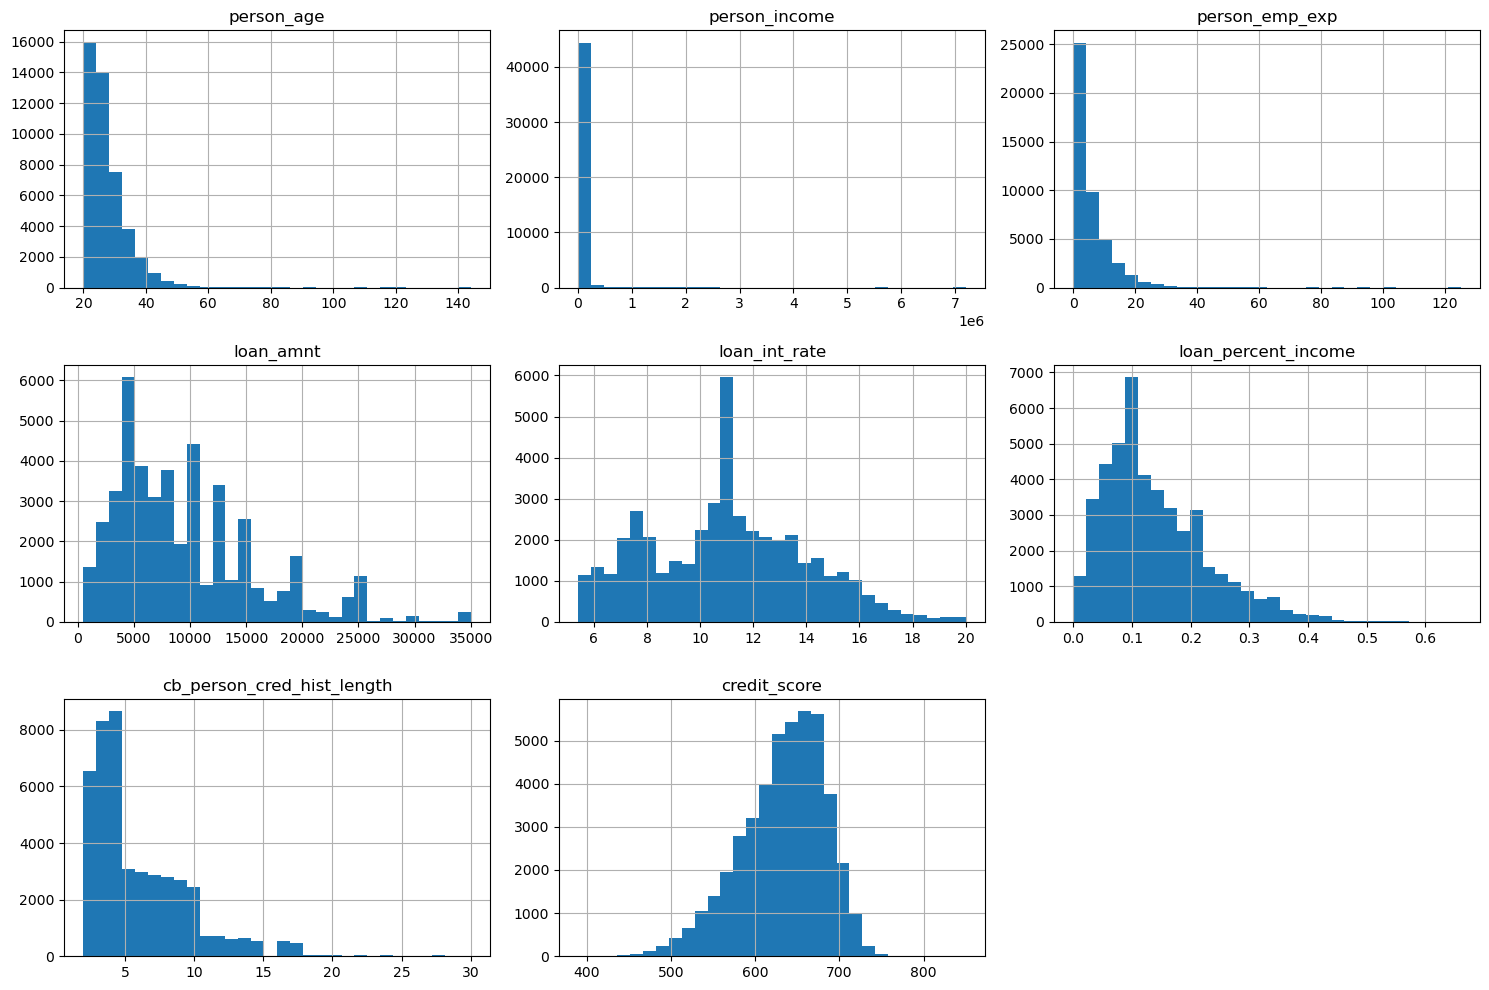

In [8]:
df[numeric_features].hist(
    figsize=(15, 10),
    bins=30
)

plt.tight_layout()
plt.show()

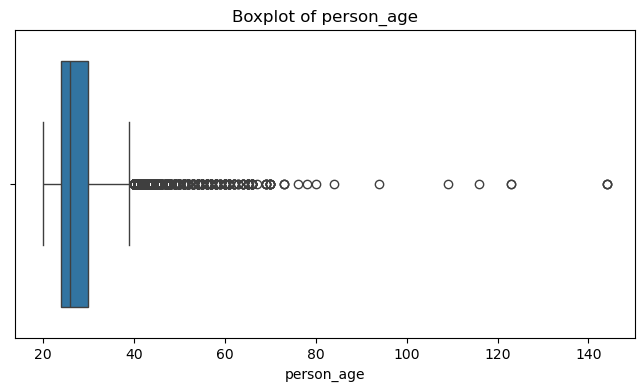

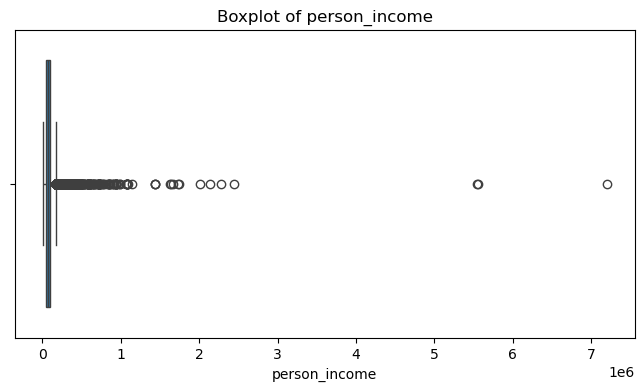

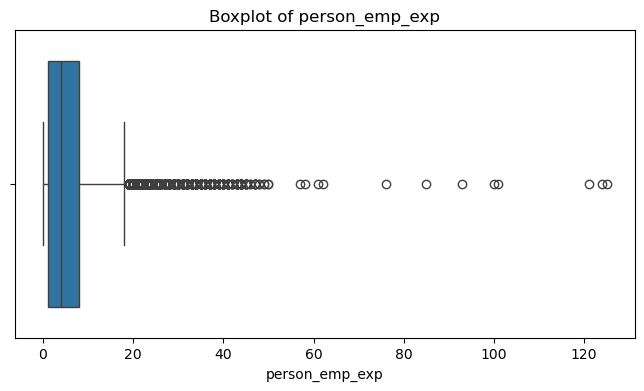

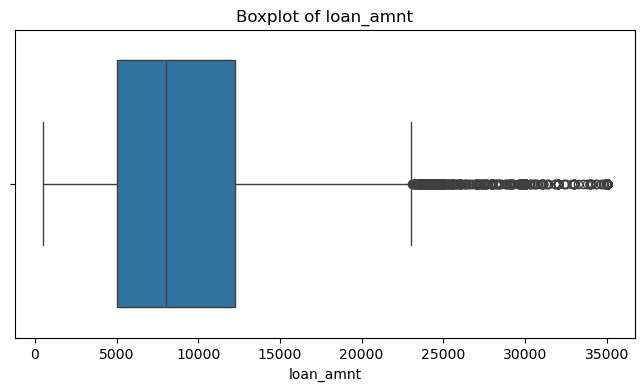

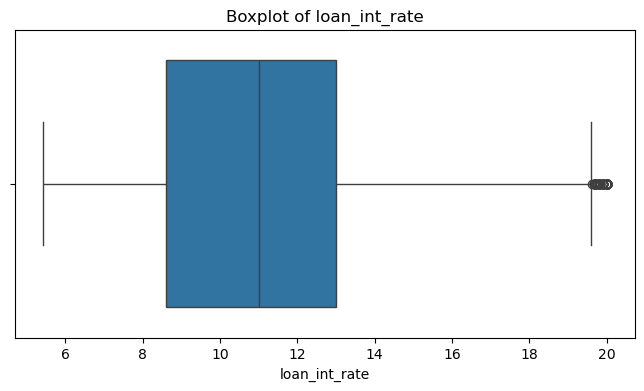

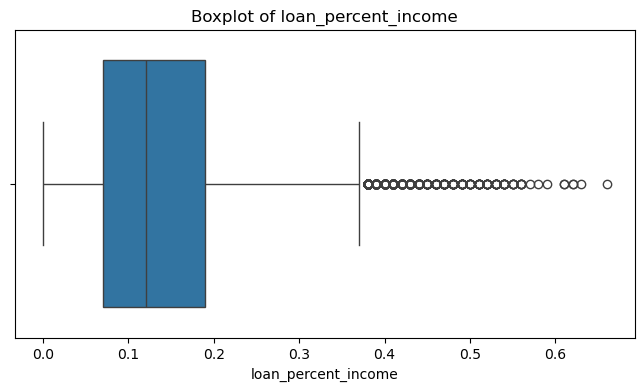

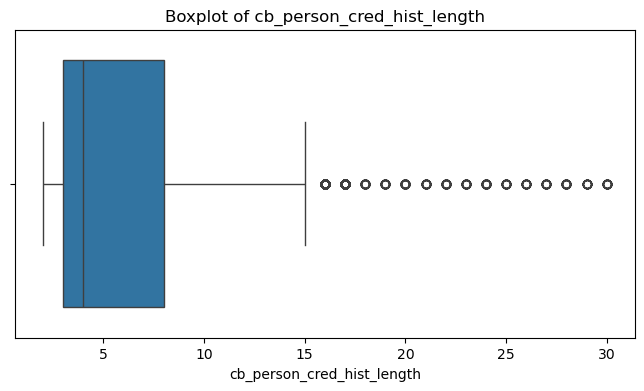

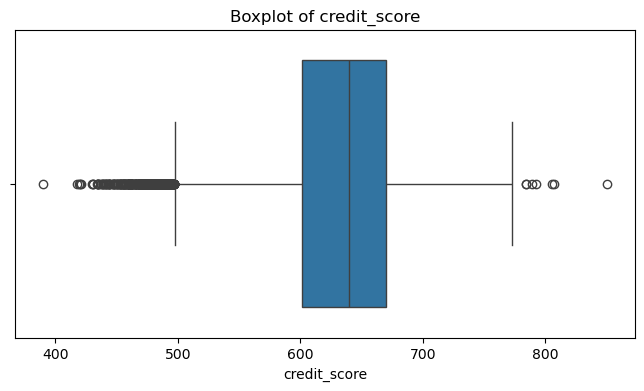

In [9]:
for col in numeric_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [10]:
categorical_features = df.select_dtypes(
    include="object"
).columns

categorical_features

Index(['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file'],
      dtype='object')

In [11]:
for col in categorical_features:
    print(f"\n{col}")
    print(df[col].value_counts())


person_gender
person_gender
male      24841
female    20159
Name: count, dtype: int64

person_education
person_education
Bachelor       13399
Associate      12028
High School    11972
Master          6980
Doctorate        621
Name: count, dtype: int64

person_home_ownership
person_home_ownership
RENT        23443
MORTGAGE    18489
OWN          2951
OTHER         117
Name: count, dtype: int64

loan_intent
loan_intent
EDUCATION            9153
MEDICAL              8548
VENTURE              7819
PERSONAL             7552
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: count, dtype: int64

previous_loan_defaults_on_file
previous_loan_defaults_on_file
Yes    22858
No     22142
Name: count, dtype: int64


In [12]:
pd.crosstab(
    df["person_home_ownership"],
    df["loan_status"],
    normalize="index"
) * 100

loan_status,0,1
person_home_ownership,,
MORTGAGE,88.403916,11.596084
OTHER,66.666667,33.333333
OWN,92.477126,7.522874
RENT,67.602269,32.397731


In [13]:
pd.crosstab(
    df["loan_intent"],
    df["loan_status"],
    normalize="index"
) * 100

loan_status,0,1
loan_intent,,
DEBTCONSOLIDATION,69.727082,30.272918
EDUCATION,83.043811,16.956189
HOMEIMPROVEMENT,73.698516,26.301484
MEDICAL,72.180627,27.819373
PERSONAL,79.859640,20.140360
VENTURE,85.573603,14.426397


In [14]:
pd.crosstab(
    df["previous_loan_defaults_on_file"],
    df["loan_status"],
    normalize="index"
) * 100

loan_status,0,1
previous_loan_defaults_on_file,,
No,54.836961,45.163039
Yes,100.000000,0.000000


In [15]:
df.groupby("loan_status")[numeric_features].mean()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score
loan_status,,,,,,,,
0,27.833571,86157.040743,5.476714,9219.576914,10.477981,0.121783,5.898286,632.814914
1,27.521300,59886.096900,5.178000,10855.689800,12.856794,0.202521,5.759700,631.887200


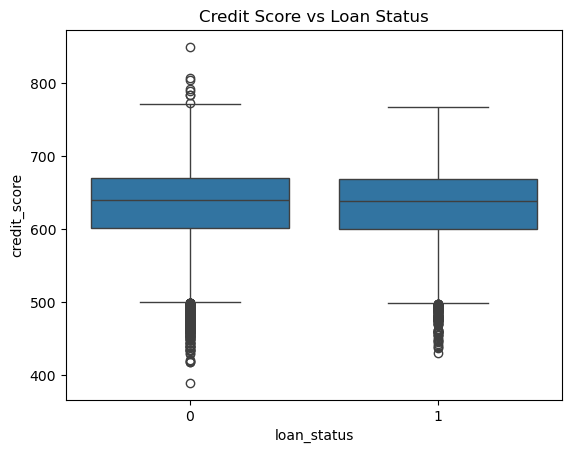

In [16]:
sns.boxplot(
    data=df,
    x="loan_status",
    y="credit_score"
)

plt.title("Credit Score vs Loan Status")
plt.show()

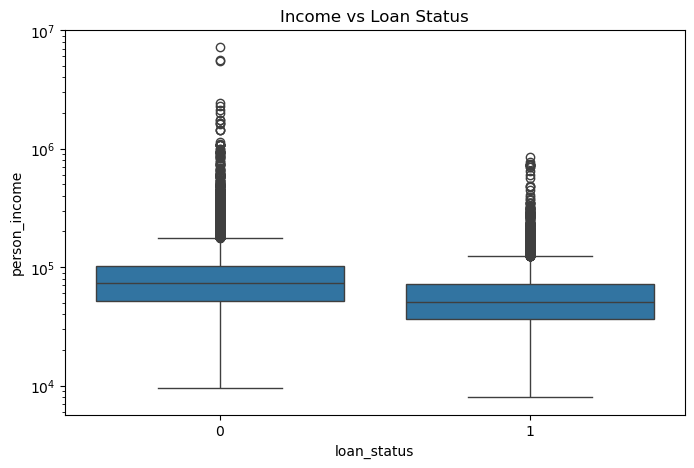

In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="loan_status",
    y="person_income"
)

plt.yscale("log")
plt.title("Income vs Loan Status")
plt.show()

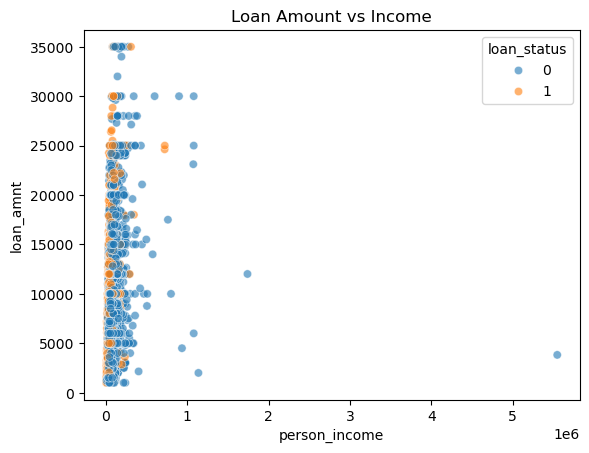

In [19]:
sns.scatterplot(
    data=df.sample(5000),
    x="person_income",
    y="loan_amnt",
    hue="loan_status",
    alpha=0.6
)

plt.title("Loan Amount vs Income")
plt.show()

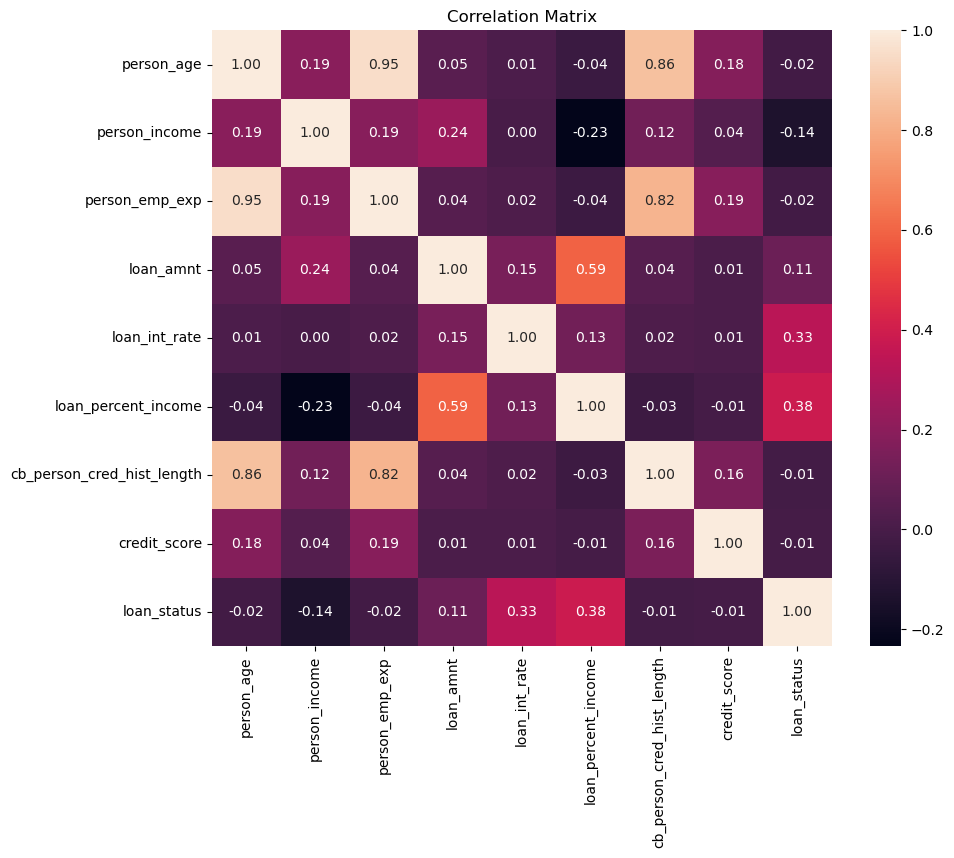

In [20]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df[numeric_features + ["loan_status"]].corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [21]:
pd.crosstab(
    df["previous_loan_defaults_on_file"],
    df["loan_status"],
    normalize="index"
) * 100

loan_status,0,1
previous_loan_defaults_on_file,,
No,54.836961,45.163039
Yes,100.000000,0.000000
